<center>

# Converger

</center>

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.renderers.default = "iframe"


In [2]:
# file = "2026-10-05_07-27-45_f_channeling_[110]_dataset_20x185_in_0.1.npz"  # First without big error
# file = "2026-10-05_17-43-26_f_channeling_[110]_dataset_50x50_in_0.1.npz"
# file = "2026-10-06_01-38-11_f_channeling_[110]_dataset_50x50_in_0.1_80DiffSpots.npz"
# file = "2026-10-06_08-15-39_f_channeling_[110]_dataset_50x50_in_0.1_200DiffSpots.npz"
# file = "2026-10-06_03-06-57_f_channeling_[110]_dataset_50x50_in_0.1_50kV.npz"
file = "2026-10-06_03-04-28_f_channeling_[110]_dataset_50x50_in_0.1_1000kV.npz"
# file = "2026-10-06_05-49-52_f_channeling_[110]_dataset_50x50_in_0.1_thickness250.npz"
# file = "2026-10-06_05-49-31_f_channeling_[110]_dataset_50x50_in_0.1_thickness1000.npz"
# file = "2026-10-06_05-59-15_f_channeling_[110]_dataset_50x50_in_0.1_thickness1500.npz"


file_path = Path("/cluster/work/gregorg/master_thesis/data/f_channeling/" + file)
figure_folder = Path("/cluster/work/gregorg/master_thesis/figure")

alpha_mrad = 10  # Convergence Semianlge


### Converged-beam channeling

The converged beam is treated as an incoherent average of the parallel-beam directions inside the convergence semi-angle $\alpha$.

Ga and As are averaged separately:

$$
J_{\mathrm{Ga}}^{\mathrm{conv}}=\langle J_{\mathrm{Ga}}\rangle,
\qquad
J_{\mathrm{As}}^{\mathrm{conv}}=\langle J_{\mathrm{As}}\rangle.
$$

The channeling factor is then

$$
f_{\mathrm{channeling}}^{\mathrm{conv}}
=
\frac{\langle J_{\mathrm{As}}\rangle}
{\langle J_{\mathrm{Ga}}\rangle}.
$$

Importantly,

$$
\left\langle
\frac{J_{\mathrm{As}}}{J_{\mathrm{Ga}}}
\right\rangle
\neq
\frac{\langle J_{\mathrm{As}}\rangle}
{\langle J_{\mathrm{Ga}}\rangle}.
$$

Loaded: /cluster/work/gregorg/master_thesis/data/f_channeling/2026-10-06_03-04-28_f_channeling_[110]_dataset_50x50_in_0.1_1000kV.npz
Stored arrays: ['dtheta', 'dpsi', 'J_Ga_map', 'J_As_map', 'f_map', 'theta_deg', 'psi_deg', 'thickness_A']
Map centre: theta = 90.00°, psi = 45.00°
Convergence semi-angle: 10.000 mrad
                       0.57296 deg
Theta step: 0.10000 deg
Psi step:   0.10000 deg

Radius    6 pixels

Converged-beam channeling ratio As/Ga
Minimum: 0.775213
Maximum: 1.296629
Average: 1.000253


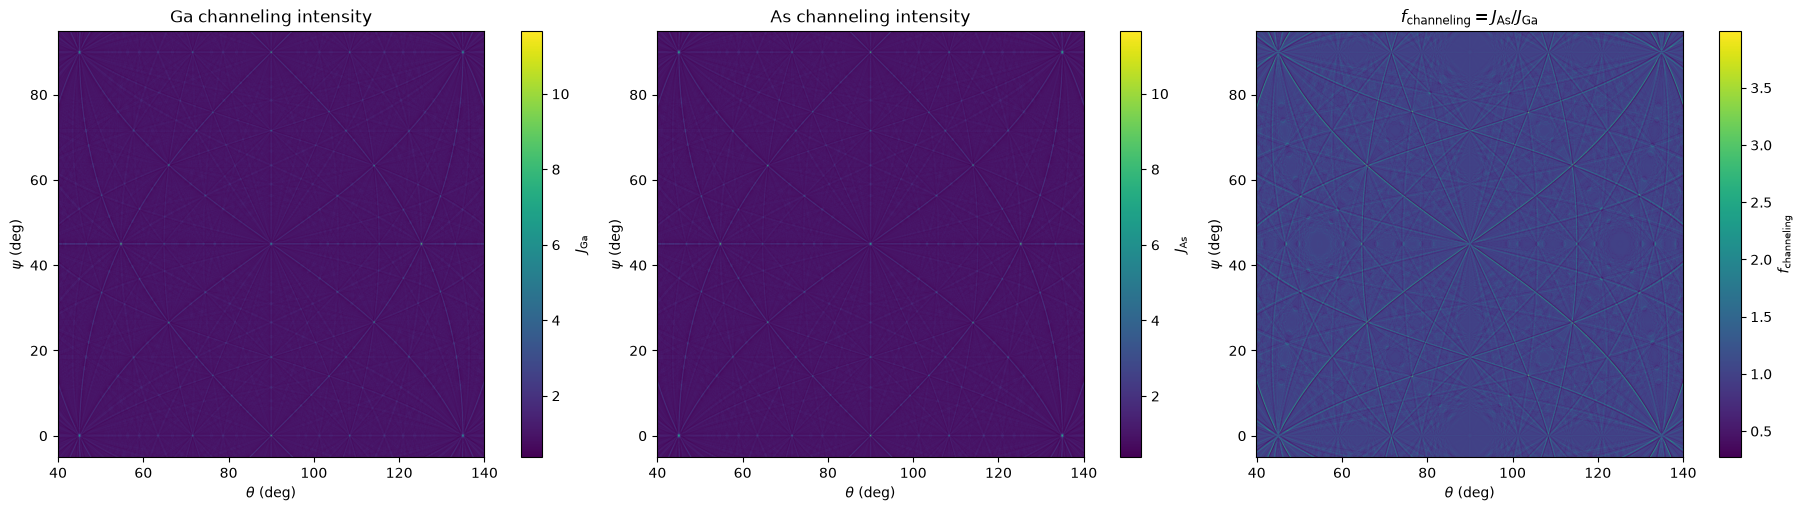

In [3]:
data = np.load(file_path)

print("Loaded:", file_path)
print("Stored arrays:", data.files)


# Load data
dtheta = data["dtheta"]
dpsi   = data["dpsi"]

J_Ga_map = data["J_Ga_map"]
J_As_map = data["J_As_map"]
f_map    = data["f_map"]



# Central zone axis of this dataset
zone_hkl = np.array([1.0, 1.0, 0.0])
zone_unit = zone_hkl / np.linalg.norm(zone_hkl)

theta0_deg = np.rad2deg(
    np.arccos(zone_unit[2])
)

psi0_deg = np.rad2deg(
    np.arctan2(zone_unit[1], zone_unit[0])
)

print(
    f"Map centre: theta = {theta0_deg:.2f}°, "
    f"psi = {psi0_deg:.2f}°"
)


# Convert offsets to global angles
theta_global = theta0_deg + dtheta
psi_global   = psi0_deg + dpsi


extent = [
    theta_global.min(),
    theta_global.max(),
    psi_global.min(),
    psi_global.max()
]


# Plot Ga, As and channeling ratio
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    constrained_layout=True
)


# Ga
im0 = axes[0].imshow(
    J_Ga_map,
    origin="lower",
    extent=extent,
    aspect="equal"
)

axes[0].set_title("Ga channeling intensity")
axes[0].set_xlabel(r"$\theta$ (deg)")
axes[0].set_ylabel(r"$\psi$ (deg)")

fig.colorbar(
    im0,
    ax=axes[0],
    label=r"$J_{\mathrm{Ga}}$"
)


# As
im1 = axes[1].imshow(
    J_As_map,
    origin="lower",
    extent=extent,
    aspect="equal"
)

axes[1].set_title("As channeling intensity")
axes[1].set_xlabel(r"$\theta$ (deg)")
axes[1].set_ylabel(r"$\psi$ (deg)")

fig.colorbar(
    im1,
    ax=axes[1],
    label=r"$J_{\mathrm{As}}$"
)


# Channeling factor
im2 = axes[2].imshow(
    f_map,
    origin="lower",
    extent=extent,
    aspect="equal"
)

axes[2].set_title(
    r"$f_{\mathrm{channeling}} = J_{\mathrm{As}}/J_{\mathrm{Ga}}$"
)

axes[2].set_xlabel(r"$\theta$ (deg)")
axes[2].set_ylabel(r"$\psi$ (deg)")

fig.colorbar(
    im2,
    ax=axes[2],
    label=r"$f_{\mathrm{channeling}}$"
)


fig.show()
# convert mrad -> degrees
alpha_deg = np.rad2deg(alpha_mrad * 1e-3)

print(f"Convergence semi-angle: {alpha_mrad:.3f} mrad")
print(f"                       {alpha_deg:.5f} deg")

# ANGULAR STEP SIZE OF SAVED PARALLEL-BEAM MAP
step_theta = np.abs(dtheta[1] - dtheta[0])
step_psi   = np.abs(dpsi[1] - dpsi[0])

print(f"Theta step: {step_theta:.5f} deg")
print(f"Psi step:   {step_psi:.5f} deg")


#  BUILD CIRCULAR CONVERGENCE KERNEL
radius_theta = int(np.ceil(alpha_deg / step_theta))
radius_psi   = int(np.ceil(alpha_deg / step_psi))

x = np.arange(
    -radius_theta,
    radius_theta + 1
) * step_theta

y = np.arange(
    -radius_psi,
    radius_psi + 1
) * step_psi

X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)

# circular aperture
kernel = (R <= alpha_deg).astype(float)

# normalize so total beam intensity = 1
kernel /= kernel.sum()


print()

print("Radius   ", radius_psi, "pixels")

J_Ga_conv_full = fftconvolve(
    J_Ga_map,
    kernel,
    mode="same"
)

J_As_conv_full = fftconvolve(
    J_As_map,
    kernel,
    mode="same"
)


# CROP EDGES
if radius_psi > 0:
    psi_slice = slice(radius_psi, -radius_psi)
else:
    psi_slice = slice(None)

if radius_theta > 0:
    theta_slice = slice(radius_theta, -radius_theta)
else:
    theta_slice = slice(None)


J_Ga_conv = J_Ga_conv_full[
    psi_slice,
    theta_slice
]

J_As_conv = J_As_conv_full[
    psi_slice,
    theta_slice
]

dpsi_conv = dpsi[psi_slice]
dtheta_conv = dtheta[theta_slice]


f_conv_map = J_As_conv / J_Ga_conv


f_min = np.nanmin(f_conv_map)
f_max = np.nanmax(f_conv_map)
f_avg = np.nanmean(f_conv_map)


print()
print("Converged-beam channeling ratio As/Ga")
print(f"Minimum: {f_min:.6f}")
print(f"Maximum: {f_max:.6f}")
print(f"Average: {f_avg:.6f}")

In [4]:
# Centre orientation of the saved [110] map
zone_hkl = np.array([1.0, 1.0, 0.0])
zone_unit = zone_hkl / np.linalg.norm(zone_hkl)

theta0_deg = np.rad2deg(np.arccos(zone_unit[2]))
psi0_deg = np.rad2deg(np.arctan2(zone_unit[1], zone_unit[0]))

# Absolute angles corresponding to every map pixel
Theta_abs, Psi_abs = np.meshgrid(
    theta0_deg + dtheta_conv,
    psi0_deg + dpsi_conv
)

angle_data = np.stack((Theta_abs, Psi_abs), axis=-1)


# Common colour range
J_min = min(np.nanmin(J_Ga_conv), np.nanmin(J_As_conv))
J_max = max(np.nanmax(J_Ga_conv), np.nanmax(J_As_conv))


fig_GaAs = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Ga — converged beam", "As — converged beam"),
    horizontal_spacing=0.06
)


# Ga
fig_GaAs.add_trace(
    go.Heatmap(
        x=theta0_deg + dtheta_conv,
        y=psi0_deg + dpsi_conv,
        z=J_Ga_conv,
        customdata=angle_data,
        coloraxis="coloraxis",

        hovertemplate=(
            "<b>Ga</b><br>"
            "θ = %{customdata[0]:.4f}°<br>"
            "ψ = %{customdata[1]:.4f}°<br>"
            "J = %{z:.6f}"
            "<extra></extra>"
        )
    ),
    row=1,
    col=1
)


# As
fig_GaAs.add_trace(
    go.Heatmap(
        x=theta0_deg + dtheta_conv,
        y=psi0_deg + dpsi_conv,
        z=J_As_conv,
        customdata=angle_data,
        coloraxis="coloraxis",

        hovertemplate=(
            "<b>As</b><br>"
            "θ = %{customdata[0]:.4f}°<br>"
            "ψ = %{customdata[1]:.4f}°<br>"
            "J = %{z:.6f}"
            "<extra></extra>"
        )
    ),
    row=1,
    col=2
)


fig_GaAs.update_layout(
    coloraxis=dict(
        colorscale="Viridis",
        cmin=J_min,
        cmax=J_max,
        colorbar=dict(
            title="Channeling intensity J",
            thickness=20,
            len=0.85
        )
    ),

    width=1700,
    height=850,

    title=dict(
        text=(
            "Ga and As converged channeling"
            f"<br><sup>α = {alpha_mrad:.1f} mrad</sup>"
        ),
        x=0.5
    ),

    margin=dict(l=70, r=120, t=100, b=70)
)


# Keep the axes as offsets from the zone axis
fig_GaAs.update_xaxes(title_text="θ (deg)")
fig_GaAs.update_yaxes(title_text="ψ (deg)")

fig_GaAs.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    row=1,
    col=1
)

fig_GaAs.update_yaxes(
    scaleanchor="x2",
    scaleratio=1,
    row=1,
    col=2
)

fig_GaAs.update_xaxes(matches="x")
fig_GaAs.update_yaxes(matches="y")

fig_GaAs.show()

In [5]:
#Converged Ga/As channeling figure
f_low, f_high = np.nanpercentile(f_conv_map, [1, 99])

f_span = max(abs(f_low - 1.0), abs(f_high - 1.0))
if f_span == 0:
    f_span = 0.01

f_min_plot = 1.0 - f_span
f_max_plot = 1.0 + f_span



theta_plot = theta0_deg + dtheta_conv
psi_plot   = psi0_deg + dpsi_conv

Theta_abs, Psi_abs = np.meshgrid(theta_plot, psi_plot)
angle_data = np.stack((Theta_abs, Psi_abs), axis=-1)


fig_fraction = go.Figure(
    go.Heatmap(
        x=theta_plot,
        y=psi_plot,
        z=f_conv_map,
        customdata=angle_data,
        colorscale="Viridis",
        zmin=f_min_plot,
        zmax=f_max_plot,
        zmid=1.0,
        colorbar=dict(title="As / Ga"),
        hovertemplate=(
            "θ = %{customdata[0]:.4f}°<br>"
            "ψ = %{customdata[1]:.4f}°<br>"
            "As / Ga = %{z:.6f}"
            "<extra></extra>"
        )
    )
)

fig_fraction.update_xaxes(title="θ (deg)")
fig_fraction.update_yaxes(
    title="ψ (deg)",
    scaleanchor="x",
    scaleratio=1
)

fig_fraction.update_layout(
    width=1000,
    height=1000,
    title=dict(
        text=f"GaAs converged channeling map — α = {alpha_mrad:.1f} mrad",
        x=0.5
    )
)

fig_fraction.show()


# Save as PDF and PNG
name = Path(file).stem

fig_save, ax = plt.subplots(
    figsize=(10, 10)
)

im = ax.imshow(
    f_conv_map,
    origin="lower",
    extent=[
        theta_plot.min(),
        theta_plot.max(),
        psi_plot.min(),
        psi_plot.max()
    ],
    cmap="viridis",
    vmin=f_min_plot,
    vmax=f_max_plot,
    aspect="equal",
    interpolation="nearest"
)

ax.set_xlabel("θ (deg)")
ax.set_ylabel("ψ (deg)")

ax.set_title(
    f"GaAs converged channeling map — α = {alpha_mrad:.1f} mrad",
    pad=18
)

# Use exactly the same displayed angular range
ax.set_xlim(theta_plot.min(), theta_plot.max())
ax.set_ylim(psi_plot.min(), psi_plot.max())

# Thin colourbar similar to Plotly
cbar = fig_save.colorbar(
    im,
    ax=ax,
    fraction=0.035,
    pad=0.03,
    shrink= 1.0,
    aspect=28
    
)

cbar.ax.set_title(
    "As / Ga",
    pad=8
)

# Keep the plotting area square
ax.set_box_aspect(1)

fig_save.tight_layout()

fig_save.savefig(figure_folder / f"{name}_{alpha_mrad}mrad.pdf", bbox_inches="tight")

fig_save.savefig(figure_folder / f"{name}_{alpha_mrad}mrad.png", dpi=300, bbox_inches="tight")

plt.close(fig_save)

In [6]:
# Centre of the calculated map
zone_hkl = np.array([1.0, 1.0, 0.0])
zone_unit = zone_hkl / np.linalg.norm(zone_hkl)

theta0_deg = np.rad2deg(np.arccos(zone_unit[2]))
psi0_deg   = np.rad2deg(np.arctan2(zone_unit[1], zone_unit[0]))

print(f"World-map centre: theta = {theta0_deg:.2f}°, psi = {psi0_deg:.2f}°")


# Map coordinates
DTHETA, DPSI = np.meshgrid(dtheta_conv, dpsi_conv)

THETA_deg = theta0_deg + DTHETA
PSI_deg   = psi0_deg + DPSI

THETA = np.deg2rad(THETA_deg)
PSI   = np.deg2rad(PSI_deg)


# Slight relief from the converged map
fmin = np.nanmin(f_conv_map)
fmax = np.nanmax(f_conv_map)

if fmax > fmin:
    f_norm = (f_conv_map - fmin) / (fmax - fmin)
else:
    f_norm = np.zeros_like(f_conv_map)

relief = 0.08
R = 1.01 + relief * f_norm

X_map = R * np.sin(THETA) * np.cos(PSI)
Y_map = R * np.sin(THETA) * np.sin(PSI)
Z_map = R * np.cos(THETA)


# Background sphere
theta_sphere = np.linspace(0, np.pi, 90)
psi_sphere   = np.linspace(-np.pi, np.pi, 180)

TH_sphere, PS_sphere = np.meshgrid(theta_sphere, psi_sphere)

X_sphere = np.sin(TH_sphere) * np.cos(PS_sphere)
Y_sphere = np.sin(TH_sphere) * np.sin(PS_sphere)
Z_sphere = np.cos(TH_sphere)


fig_world = go.Figure()

fig_world.add_trace(
    go.Surface(
        x=X_sphere,
        y=Y_sphere,
        z=Z_sphere,
        surfacecolor=np.zeros_like(X_sphere),
        colorscale=[[0, "lightgray"], [1, "lightgray"]],
        opacity=0.18,
        showscale=False,
        hoverinfo="skip"
    )
)


# Hover should show absolute angles
customdata = np.stack((THETA_deg, PSI_deg), axis=-1)

fig_world.add_trace(
    go.Surface(
        x=X_map,
        y=Y_map,
        z=Z_map,
        surfacecolor=f_conv_map,
        colorscale="Viridis",
        cmin=f_min_plot,
        cmax=f_max_plot,
        cmid=1.0,
        colorbar=dict(
            title="As / Ga",
            len=0.65
        ),
        customdata=customdata,
        hovertemplate=(
            "θ = %{customdata[0]:.4f}°<br>"
            "ψ = %{customdata[1]:.4f}°<br>"
            "As / Ga = %{surfacecolor:.6f}"
            "<extra></extra>"
        )
    )
)


# Low-index zone directions
zone_xyz = []
zone_labels = []

for h in (-1, 0, 1):
    for k in (-1, 0, 1):
        for l in (-1, 0, 1):
            if h == 0 and k == 0 and l == 0:
                continue

            v = np.array([h, k, l], dtype=float)
            v /= np.linalg.norm(v)

            zone_xyz.append(1.13 * v)
            zone_labels.append(f"[{h} {k} {l}]")

zone_xyz = np.array(zone_xyz)

fig_world.add_trace(
    go.Scatter3d(
        x=zone_xyz[:, 0],
        y=zone_xyz[:, 1],
        z=zone_xyz[:, 2],
        mode="markers+text",
        marker=dict(size=4, color="#0065BD"),
        text=zone_labels,
        textposition="top center",
        textfont=dict(size=10),
        hovertemplate="<b>%{text}</b><extra></extra>",
        name="Zone axes"
    )
)


# Highlight current zone
fig_world.add_trace(
    go.Scatter3d(
        x=[1.15 * zone_unit[0]],
        y=[1.15 * zone_unit[1]],
        z=[1.15 * zone_unit[2]],
        mode="markers+text",
        marker=dict(size=7),
        text=["[110]"],
        textposition="top center",
        hovertemplate="[110] — centre of calculated map<extra></extra>",
        name="[110]"
    )
)


fig_world.update_layout(
    width=1700,
    height=900,
    title=dict(
        text=(
            f"GaAs converged channeling — spherical orientation map"
            f"<br>α = {alpha_mrad:.1f} mrad"
        ),
        x=0.5
    ),
    scene=dict(
        aspectmode="cube",
        xaxis=dict(title="[100]", range=[-1.25, 1.25]),
        yaxis=dict(title="[010]", range=[-1.25, 1.25]),
        zaxis=dict(title="[001]", range=[-1.25, 1.25]),
        camera=dict(
            eye=dict(x=1.45, y=1.45, z=1.15)
        )
    ),
    margin=dict(l=0, r=0, b=0, t=80)
)

fig_world.show()

World-map centre: theta = 90.00°, psi = 45.00°
